 TÍTULO E OBJETIVO

# Análise Exploratória de Dados de RH

Este notebook apresenta uma Análise Exploratória de Dados (EDA) sobre salários,
departamentos, cargos e regiões, utilizando os arquivos `query_01.csv` e
`query_02.csv` extraídos do schema HR do FreeSQL.

1- IMPORTAÇÃO DAS BIBLIOTECAS 

In [31]:
print('Importando as bibliotecas necessárias ')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print('Bibliotecas importadas com sucesso!')

print('Configurando o estilo das visualizações ')
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
print('Estilo configurado com sucesso!')

Importando as bibliotecas necessárias 
Bibliotecas importadas com sucesso!
Configurando o estilo das visualizações 
Estilo configurado com sucesso!


2- LEITURA DE ARQUIVOS CSV'S E EXIBINDO AS PRIMEIRAS LINHAS

In [32]:
print('Carregando os dados das consultas SQL...')
df_q1 = pd.read_csv("../dados/query_01.csv")
df_q2 = pd.read_csv("../dados/query_02.csv")
print('Dados carregados com sucesso!')
print()

print('Exibindo as primeiras linhas do DataFrame df_q1:')
df_q1.head()

Carregando os dados das consultas SQL...
Dados carregados com sucesso!

Exibindo as primeiras linhas do DataFrame df_q1:


,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_ID,DEPARTMENT_NAME,JOB_ID,JOB_TITLE,MIN_SALARY,MAX_SALARY
0,205,Shelley,Higgins,12008,110.0,Accounting,AC_MGR,Accounting Manager,8200,16000
1,206,William,Gietz,8300,110.0,Accounting,AC_ACCOUNT,Public Accountant,4200,9000
2,200,Jennifer,Whalen,4400,10.0,Administration,AD_ASST,Administration Assistant,3000,6000
3,102,Lex,Garcia,17000,90.0,Executive,AD_VP,Administration Vice President,15000,30000
4,101,Neena,Yang,17000,90.0,Executive,AD_VP,Administration Vice President,15000,30000


In [33]:
print('Exibindo as primeiras linhas do DataFrame df_q2:')
df_q2.head()

Exibindo as primeiras linhas do DataFrame df_q2:


,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_ID,DEPARTMENT_NAME,LOCATION_ID,CITY,STATE_PROVINCE,COUNTRY_ID,COUNTRY_NAME,REGION_ID,REGION_NAME
0,201,Michael,Martinez,13000,20,Marketing,1800,Toronto,Ontario,CA,Canada,20,Americas
1,202,Pat,Davis,6000,20,Marketing,1800,Toronto,Ontario,CA,Canada,20,Americas
2,100,Steven,King,24000,90,Executive,1700,Seattle,Washington,US,United States of America,20,Americas
3,102,Lex,Garcia,17000,90,Executive,1700,Seattle,Washington,US,United States of America,20,Americas
4,101,Neena,Yang,17000,90,Executive,1700,Seattle,Washington,US,United States of America,20,Americas


3- CÓPIA DOS DADOS ORIGINAIS

In [34]:
df_q1_raw = df_q1.copy()
df_q2_raw = df_q2.copy()

4- RENOMEAÇÃO DAS COLUNAS (QUERY 1) - (QUERY 2)

In [35]:
print('Query 1 - Renomeando colunas para melhor compreensão e traduzindo para português...')
df_q1 = df_q1_raw.rename(columns={
    "EMPLOYEE_ID": "id_funcionario",
    "FIRST_NAME": "nome",
    "LAST_NAME": "sobrenome",
    "SALARY": "salario",
    "DEPARTMENT_ID": "id_departamento",
    "DEPARTMENT_NAME": "nome_departamento",
    "JOB_ID": "id_cargo",
    "JOB_TITLE": "cargo",
    "MIN_SALARY": "salario_minimo_cargo",
    "MAX_SALARY": "salario_maximo_cargo"
})
print("Colunas Query 1 (pt-br):")
print(df_q1.columns.tolist())

print('Query 2 - Renomeando colunas para melhor compreensão e traduzindo para português...')
df_q2 = df_q2_raw.rename(columns={
    "EMPLOYEE_ID": "id_funcionario",
    "FIRST_NAME": "nome",
    "LAST_NAME": "sobrenome",
    "SALARY": "salario",
    "DEPARTMENT_ID": "id_departamento",
    "DEPARTMENT_NAME": "nome_departamento",
    "LOCATION_ID": "id_local",
    "CITY": "cidade",
    "STATE_PROVINCE": "estado_provincia",
    "COUNTRY_ID": "id_pais",
    "COUNTRY_NAME": "pais",
    "REGION_ID": "id_regiao",
    "REGION_NAME": "regiao"
})
print("Colunas Query 2 (pt-br):")
print(df_q2.columns.tolist())

Query 1 - Renomeando colunas para melhor compreensão e traduzindo para português...
Colunas Query 1 (pt-br):
['id_funcionario', 'nome', 'sobrenome', 'salario', 'id_departamento', 'nome_departamento', 'id_cargo', 'cargo', 'salario_minimo_cargo', 'salario_maximo_cargo']
Query 2 - Renomeando colunas para melhor compreensão e traduzindo para português...
Colunas Query 2 (pt-br):
['id_funcionario', 'nome', 'sobrenome', 'salario', 'id_departamento', 'nome_departamento', 'id_local', 'cidade', 'estado_provincia', 'id_pais', 'pais', 'id_regiao', 'regiao']


4- LIMPEZA DOS DADOS

4.1- Remove qualquer linha com nulos e duplicatas

4.1.1- Valores nulos QUERY 1 e QUERY 2

In [30]:
print("=== Valores nulos por coluna - Query 1 ===")
nulos_q1 = df_q1.isnull().sum()
print(nulos_q1)

total_nulos_q1 = nulos_q1.sum()
print("\nTotal de valores nulos na Query 1:", total_nulos_q1)

print("\n=== Valores nulos por coluna - Query 2 ===")
nulos_q2 = df_q2.isnull().sum()
print(nulos_q2)

total_nulos_q2 = nulos_q2.sum()
print("\nTotal de valores nulos na Query 2:", total_nulos_q2)

=== Valores nulos por coluna - Query 1 ===
id_funcionario          0
nome                    0
sobrenome               0
salario                 0
id_departamento         0
nome_departamento       0
id_cargo                0
cargo                   0
salario_minimo_cargo    0
salario_maximo_cargo    0
dtype: int64

Total de valores nulos na Query 1: 0

=== Valores nulos por coluna - Query 2 ===
id_funcionario       0
nome                 0
sobrenome            0
salario              0
id_departamento      0
nome_departamento    0
id_local             0
cidade               0
estado_provincia     0
id_pais              0
pais                 0
id_regiao            0
regiao               0
dtype: int64

Total de valores nulos na Query 2: 0


4.1.2- Remoção dos valores nulos QUERY 1 e QUERY 2

In [37]:
df_q1 = df_q1.dropna(subset=["id_departamento", "nome_departamento"])
print("Shape após remoção QUERY 1:", df_q1.shape)
print(df_q1.isnull().sum())
print()
df_q2 = df_q2.dropna(subset=["estado_provincia"])
print("Shape após remoção QUERY 2:", df_q2.shape)
print(df_q2.isnull().sum())

Shape após remoção QUERY 1: (106, 10)
id_funcionario          0
nome                    0
sobrenome               0
salario                 0
id_departamento         0
nome_departamento       0
id_cargo                0
cargo                   0
salario_minimo_cargo    0
salario_maximo_cargo    0
dtype: int64

Shape após remoção QUERY 2: (105, 13)
id_funcionario       0
nome                 0
sobrenome            0
salario              0
id_departamento      0
nome_departamento    0
id_local             0
cidade               0
estado_provincia     0
id_pais              0
pais                 0
id_regiao            0
regiao               0
dtype: int64


4.2- Verificando se tem duplicata nas QUERY 1 e QUERY 2 e removendo se existir

4.2.1- Verificando se tem duplicata QUERY 1 e QUERY 2

In [38]:
print("=== Duplicatas na Query 1 ===")

# Número total de linhas
print("Total de linhas:", df_q1.shape[0])

# Número de linhas duplicadas (todas as colunas)
num_duplicatas_q1 = df_q1.duplicated().sum()
print("Total de linhas duplicadas:", num_duplicatas_q1)
print()
print("=== Duplicatas na Query 2 ===")
print("Total de linhas:", df_q2.shape[0])
num_duplicatas_q2 = df_q2.duplicated().sum()
print("Total de linhas duplicadas:", num_duplicatas_q2)
print()


=== Duplicatas na Query 1 ===
Total de linhas: 106
Total de linhas duplicadas: 0

=== Duplicatas na Query 2 ===
Total de linhas: 105
Total de linhas duplicadas: 0



## ANÁLISE EXPLORATÓRIA EDA

## 5- Estatística descritiva 

In [43]:
print("\n" + "=" * 40)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 40)

print("\nQuery 1 - Estatísticas salariais")
print("Média:", df_q1["salario"].mean().round(2))
print("Mediana:", df_q1["salario"].median().round(2))
print("Desvio padrão:", df_q1["salario"].std().round(2))
print("Máximo:", df_q1["salario"].max().round(2))
print("Mínimo:", df_q1["salario"].min().round(2))
print(df_q1["salario"].describe())

print("\nQuery 2 - Estatísticas salariais")
print("Média:", df_q2["salario"].mean().round(2))
print("Mediana:", df_q2["salario"].median().round(2))
print("Desvio padrão:", df_q2["salario"].std().round(2))
print("Máximo:", df_q2["salario"].max().round(2))
print("Mínimo:", df_q2["salario"].min().round(2))
print(df_q2["salario"].describe())


ESTATÍSTICAS DESCRITIVAS

Query 1 - Estatísticas salariais
Média: 6456.75
Mediana: 6150.0
Desvio padrão: 3927.8
Máximo: 24000
Mínimo: 2100
count      106.000000
mean      6456.754717
std       3927.798234
min       2100.000000
25%       3100.000000
50%       6150.000000
75%       8950.000000
max      24000.000000
Name: salario, dtype: float64

Query 2 - Estatísticas salariais
Média: 6456.34
Mediana: 6100.0
Desvio padrão: 3946.63
Máximo: 24000
Mínimo: 2100
count      105.000000
mean      6456.342857
std       3946.634403
min       2100.000000
25%       3100.000000
50%       6100.000000
75%       9000.000000
max      24000.000000
Name: salario, dtype: float64


6- VER FREQUÊNCIA DAS CATEGORIAS (QUERY 2)

In [44]:
print("=== Contagem de valores por categoria - Query 2 ===")
print("Departamentos:")
print(df_q2["nome_departamento"].value_counts())

print("\nRegiões:")
print(df_q2["regiao"].value_counts())


=== Contagem de valores por categoria - Query 2 ===
Departamentos:
nome_departamento
Shipping            45
Sales               34
Finance              6
Purchasing           6
IT                   5
Executive            3
Marketing            2
Accounting           2
Administration       1
Public Relations     1
Name: count, dtype: int64

Regiões:
regiao
Americas    70
Europe      35
Name: count, dtype: int64


7- COMPARAÇÕES E MÉDIAS 

7.1- Comparações salariais

In [45]:
print("\nMédia salarial por cargo (Query 1)")
media_cargo = df_q1.groupby("cargo")["salario"].mean().sort_values().round(2)
print(media_cargo)


Média salarial por cargo (Query 1)
cargo
Purchasing Clerk                    2780.00
Stock Clerk                         2785.00
Shipping Clerk                      3215.00
Administration Assistant            4400.00
Programmer                          5760.00
Marketing Representative            6000.00
Human Resources Representative      6500.00
Stock Manager                       7280.00
Accountant                          7920.00
Public Accountant                   8300.00
Sales Representative                8396.55
Public Relations Representative    10000.00
Purchasing Manager                 11000.00
Finance Manager                    12008.00
Accounting Manager                 12008.00
Sales Manager                      12200.00
Marketing Manager                  13000.00
Administration Vice President      17000.00
President                          24000.00
Name: salario, dtype: float64


In [46]:
print("\nMédia salarial por departamento (Query 2)")
media_dep = df_q2.groupby("nome_departamento")["salario"].mean().sort_values().round(2)
print(media_dep)


Média salarial por departamento (Query 2)
nome_departamento
Shipping             3475.56
Purchasing           4150.00
Administration       4400.00
IT                   5760.00
Finance              8601.33
Sales                8955.88
Marketing            9500.00
Public Relations    10000.00
Accounting          10154.00
Executive           19333.33
Name: salario, dtype: float64


In [47]:
print("\nMédia salarial por região (Query 2)")
media_regiao = df_q2.groupby("regiao")["salario"].mean().sort_values().round(2)
print(media_regiao)


Média salarial por região (Query 2)
regiao
Americas    5191.66
Europe      8985.71
Name: salario, dtype: float64


8- IDENTIFICAÇÃO DE OUTLIERS (QUERY 2)

In [48]:
q1 = df_q2["salario"].quantile(0.25)
q3 = df_q2["salario"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = df_q2[
    (df_q2["salario"] < limite_inferior) |
    (df_q2["salario"] > limite_superior)
]

print("\n" + "=" * 60)
print("OUTLIERS SALARIAIS - QUERY 2")
print("=" * 60)
print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")
print(f"Total de outliers: {outliers.shape[0]}")
print("\nExemplos de outliers:")
print(outliers[["nome", "sobrenome", "nome_departamento", "regiao", "salario"]].head())



OUTLIERS SALARIAIS - QUERY 2
Q1: 3100.00
Q3: 9000.00
IQR: 5900.00
Limite inferior: -5750.00
Limite superior: 17850.00
Total de outliers: 1

Exemplos de outliers:
     nome sobrenome nome_departamento    regiao  salario
2  Steven      King         Executive  Americas    24000


9- GRÁFICOS (QUERY 2)

9.1- Histograma - Distribuição dos salários

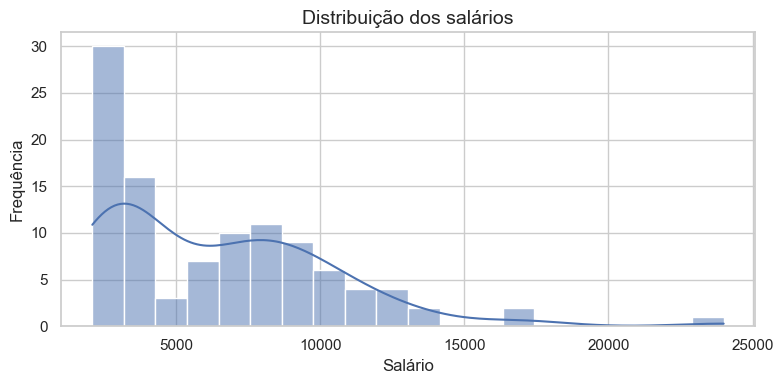

In [20]:
plt.figure(figsize=(8, 4))
sns.histplot(df_q2["salario"], bins=20, kde=True)
plt.title("Distribuição dos salários")
plt.xlabel("Salário")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

9.2- Boxplot - Salário por departamento

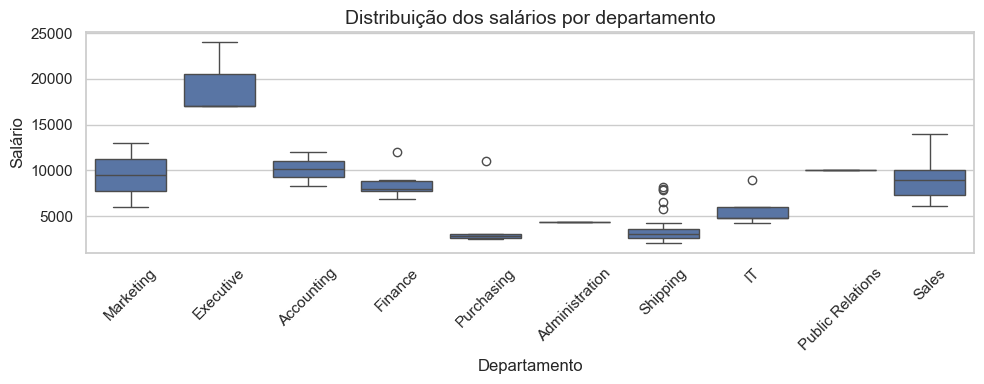

In [49]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_q2, x="nome_departamento", y="salario")
plt.title("Distribuição dos salários por departamento")
plt.xlabel("Departamento")
plt.ylabel("Salário")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

9.3- Boxplot - Salários por região

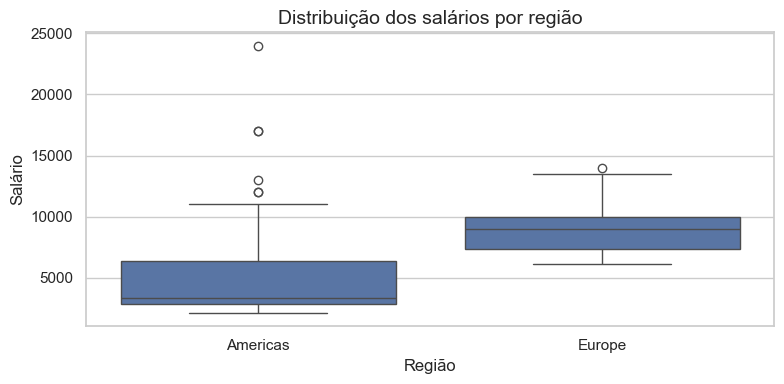

In [50]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_q2, x="regiao", y="salario")
plt.title("Distribuição dos salários por região")
plt.xlabel("Região")
plt.ylabel("Salário")
plt.tight_layout()
plt.show()

9.4- Barplot - Média salárial por região

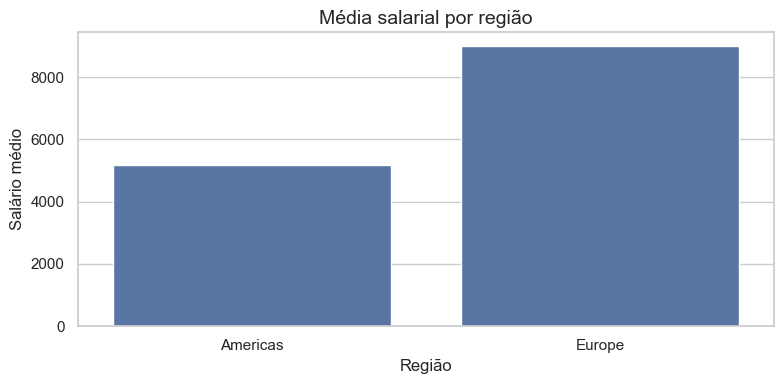

In [51]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=df_q2,
    x="regiao",
    y="salario",
    estimator="mean",
    errorbar=None   # em vez de ci=None
)
plt.title("Média salarial por região")
plt.xlabel("Região")
plt.ylabel("Salário médio")
plt.tight_layout()
plt.show()

## 9. Conclusões finais

A análise exploratória dos dados de Recursos Humanos permitiu
identificar padrões relevantes na estrutura salarial da empresa,
mostrando que a remuneração não é distribuída de forma homogênea entre
os funcionários. As estatísticas descritivas indicaram ampla variação
entre os salários mínimo e máximo, o que evidencia a presença de
diferentes níveis hierárquicos, responsabilidades e faixas de
remuneração dentro da organização.

Um dos principais insights obtidos foi a existência de assimetria na
distribuição salarial, percebida pela diferença entre média e mediana.
Esse resultado sugere que salários mais elevados exercem influência
sobre a média geral, enquanto a mediana representa de forma mais fiel o
comportamento predominante da maior parte dos funcionários.

A análise por cargo mostrou que funções estratégicas e de liderança
apresentam os maiores salários médios, enquanto cargos operacionais e
administrativos concentram valores menores e mais estáveis. Esse achado
reforça a lógica esperada de progressão salarial por responsabilidade,
mas também evidencia a importância de manter critérios claros e
equilibrados de remuneração entre os diferentes níveis da estrutura
organizacional.

Outro insight importante foi observado na comparação entre
departamentos. Alguns setores apresentaram maior dispersão salarial,
indicando maior diversidade de cargos e níveis hierárquicos, enquanto
outros mostraram remuneração mais homogênea. Esse comportamento sugere
que a estrutura interna dos departamentos influencia diretamente a
variação salarial e pode ser considerada em análises futuras de
equidade e planejamento de carreira.

Na análise por região, verificou-se que a média salarial varia entre as
localidades, o que indica a influência de fatores geográficos e
organizacionais sobre a remuneração. Esse resultado pode estar
relacionado à concentração de cargos mais altos em determinadas regiões
ou às diferenças do mercado de trabalho local, sendo um ponto relevante
para a gestão estratégica de pessoas.

A identificação de outliers salariais também trouxe um insight
importante: existem funcionários com remuneração significativamente
acima do padrão predominante da base. Esses casos podem estar
associados a posições executivas ou especializadas, mas também mostram
a necessidade de o RH acompanhar esses valores de forma criteriosa para
garantir coerência interna e transparência na política salarial.

De forma geral, os resultados obtidos demonstram que a análise
exploratória foi essencial para compreender a composição dos salários,
comparar cargos, departamentos e regiões e revelar padrões que não
seriam perceptíveis apenas pela observação bruta dos dados. Assim, os
insights gerados podem contribuir para revisões no plano de cargos e
salários, discussões sobre equidade interna e apoio à tomada de decisão
em gestão de pessoas.